RAW DATA
✓ Dataset 1 (2018-2019): 916,765 rows
✓ Dataset 2 (2020-2025): 4,581,797 rows
✓ Combined: 5,498,562 rows
✓ Total: 5,498,562 rows

✓ Memory: 11018.92 MB

CLEAN UP
✓ Columns kept: 10
✓ Unspecified boroughs removed
✓ Drop rows with no coordinates
✓ Duplicates removed
✓ Saved to /Users/thorrielishalldoruson/Downloads/311_noise_cleaned.csv
✓ File size: 868 MB
DATA SIZE
✓ Rows: 5,461,420
✓ Columns: 10
✓ Shape: (5461420, 10)

✓ Memory: 2820 MB
DATA PROPERTIES
Date range: 2018-01-01 to 2025-12-30
Geographic: Yes (borough data available)
Borough
BRONX            1518408
MANHATTAN        1438048
BROOKLYN         1360173
QUEENS           1024790
STATEN ISLAND     120001
Name: count, dtype: int64
MISSING DATA
                                      Missing Count  Missing %
Location Type                                489036       8.95
Cross Street 1                                94156       1.72
Cross Street 2                                93242       1.71
Incident Address                

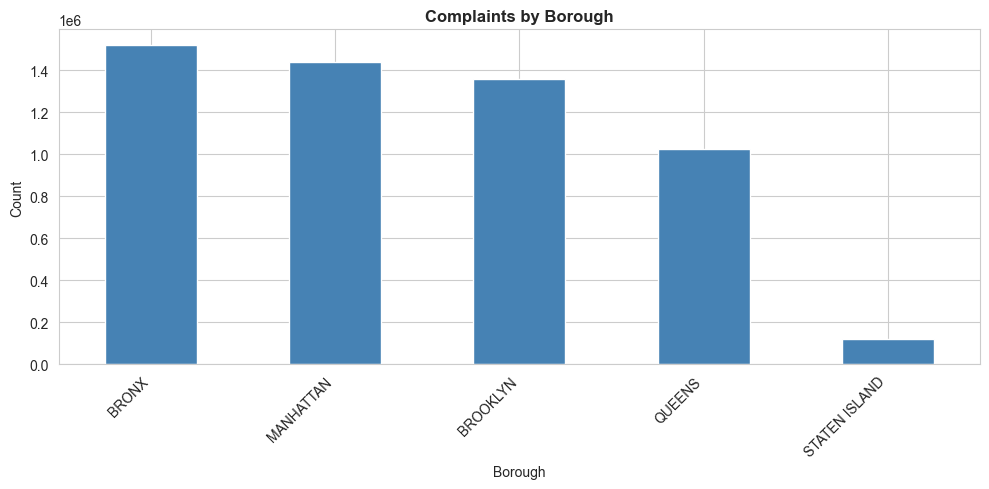

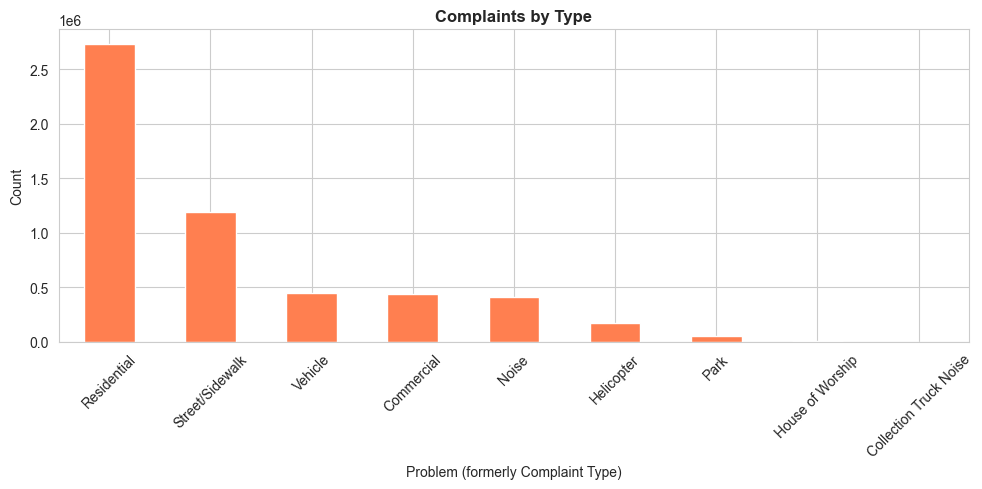

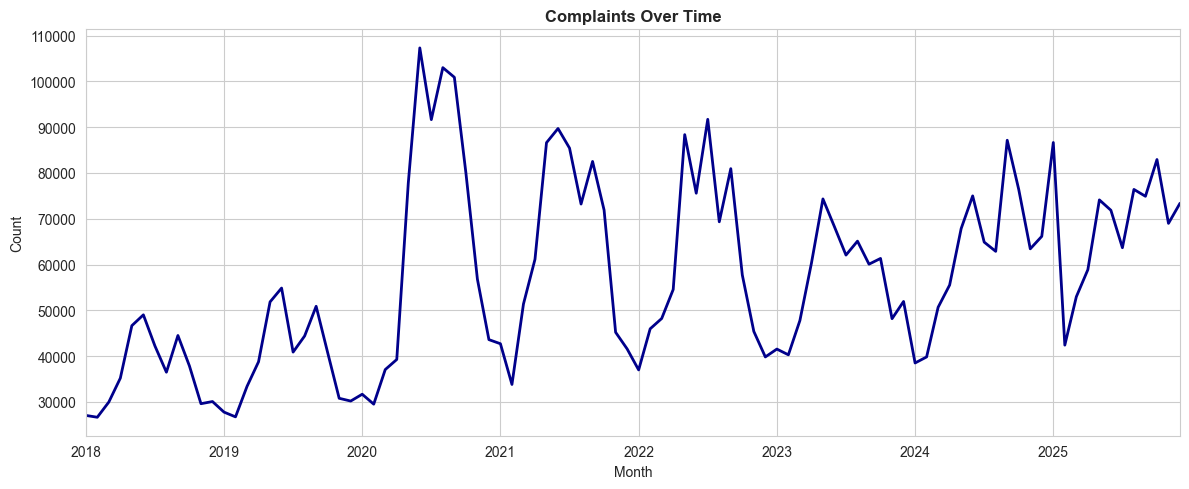

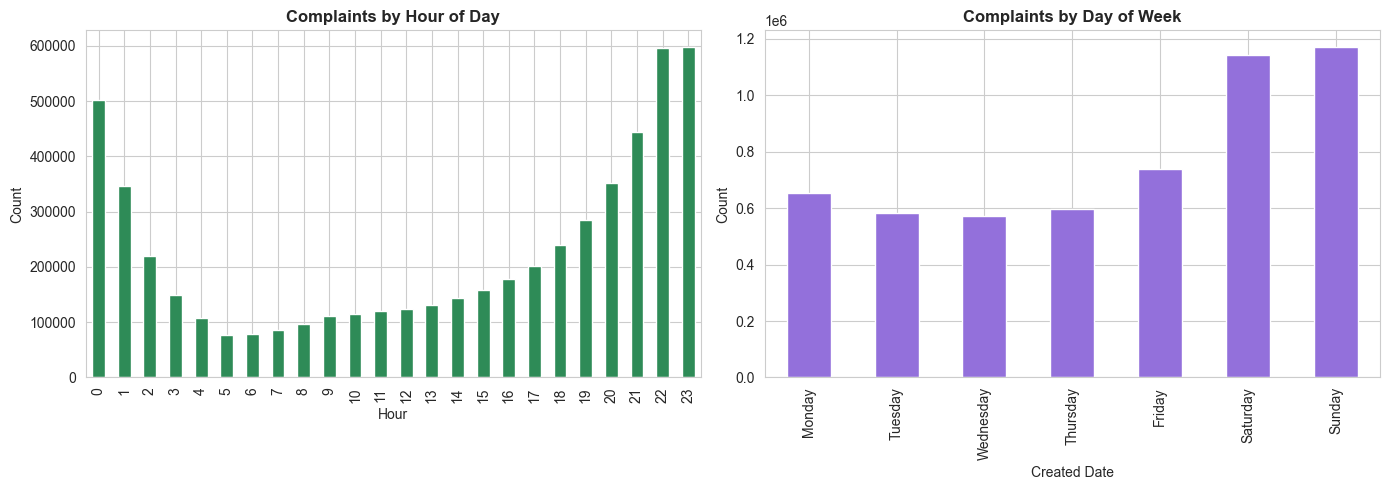

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Supress warnings globally
warnings.filterwarnings("ignore")

# Load both CSVs from Downloads
home = os.path.expanduser("~")
file_path1 = os.path.join(home, "Downloads", "311_Service_Requests_from_2018_to_2019_20260413.csv")
file_path2 = os.path.join(home, "Downloads", "311_Service_Requests_from_2020_to_2025_20260413.csv")

df1 = pd.read_csv(file_path1)
df2 = pd.read_csv(file_path2)

# Raw data stats
print("="*60)
print("RAW DATA")
print("="*60)

print(f"✓ Dataset 1 (2018-2019): {len(df1):,} rows")
print(f"✓ Dataset 2 (2020-2025): {len(df2):,} rows")

# Combine both datasets
df = pd.concat([df1, df2], ignore_index=True)
print(f"✓ Combined: {len(df):,} rows")
print(f"✓ Total: {len(df1) + len(df2):,} rows\n")
print(f"✓ Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

# Clean up
print("="*60)
print("CLEAN UP")
print("="*60)

# Clean columns
cols_to_keep = [
    'Created Date',
    'Problem (formerly Complaint Type)',
    'Problem Detail (formerly Descriptor)',
    'Location Type',
    'Borough',
    'Latitude',
    'Longitude',
    # Optional street-level
    'Incident Address',
    'Cross Street 1',
    'Cross Street 2',
]

df = df[cols_to_keep]

print(f"✓ Columns kept: {len(df.columns)}")

# Remove unspecified/null boroughs (already discussed)
df = df[(df['Borough'] != 'Unspecified') & (df['Borough'].notna())]
print(f"✓ Unspecified boroughs removed")

# Drop rows with no coordinates (useless for map visualizations)
df = df.dropna(subset=['Latitude', 'Longitude'])
print(f"✓ Drop rows with no coordinates")

# Remove duplicates
df = df.drop_duplicates()
print(f"✓ Duplicates removed")

# Save cleaned dataset
output_path = os.path.join(home, "Downloads", "311_noise_cleaned.csv")
df.to_csv(output_path, index=False)
print(f"✓ Saved to {output_path}")
print(f"✓ File size: {os.path.getsize(output_path) / 1024**2:.0f} MB")

# Data size
print("="*60)
print("DATA SIZE")
print("="*60)

print(f"✓ Rows: {len(df):,}")
print(f"✓ Columns: {len(df.columns)}")
print(f"✓ Shape: {df.shape}\n")
print(f"✓ Memory: {df.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

# Data Properties
print("="*60)
print("DATA PROPERTIES")
print("="*60)

# Date range
date_cols = [col for col in df.columns if 'date' in col.lower()]
if date_cols:
    date_col = date_cols[0]
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    print(f"Date range: {df[date_col].min().date()} to {df[date_col].max().date()}")

# Geographic
borough_cols = [col for col in df.columns if 'borough' in col.lower()]
if borough_cols:
    print(f"Geographic: Yes (borough data available)")
    print(df[borough_cols[0]].value_counts().head())

# Missing data
print("="*60)
print("MISSING DATA")
print("="*60)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df.to_string())
print(f"\nTotal columns with missing data: {len(missing_df)}")
print(f"Total missing values: {missing.sum():,}")


# Fundamental distributions
print("="*60)
print("FUNDAMENTAL DISTRIBUTIONS")
print("="*60)

sns.set_style('whitegrid')

# Plot 1: Borough
if borough_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    df[borough_cols[0]].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Complaints by Borough', fontweight='bold', fontsize=12)
    ax.set_ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Plot 2: Complaints by type
fig, ax = plt.subplots(figsize=(10, 5))
counts = df['Problem (formerly Complaint Type)'].value_counts()
counts.index = counts.index.str.replace(r'^Noise\s*-\s*', '', regex=True)
counts.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Complaints by Type', fontweight='bold', fontsize=12)
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Plot 3: Complaint types over time
if date_cols:
    complaints_per_month = df[date_col].dt.to_period('M').value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    complaints_per_month.plot(kind='line', ax=ax, color='darkblue', linewidth=2)
    ax.set_title('Complaints Over Time', fontweight='bold', fontsize=12)
    ax.set_ylabel('Count')
    ax.set_xlabel('Month')
    plt.tight_layout()
    plt.show()

# Plot 4
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Created Date'].dt.hour.value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='seagreen')
axes[0].set_title('Complaints by Hour of Day', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['Created Date'].dt.day_name().value_counts().reindex(day_order).plot(
    kind='bar', ax=axes[1], color='mediumpurple')
axes[1].set_title('Complaints by Day of Week', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [3]:
df.describe(include='all')


,Created Date,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Resolution Description,Location Type,Borough,Latitude,Longitude,Incident Address,Cross Street 1,Cross Street 2
count,5467176,5467176,5467174,5401601,4975213,5467176,5.467176e+06,5.467176e+06,5374099,5372592,5373507
unique,NaN,9,36,82,14,5,NaN,NaN,511066,16314,16530
top,NaN,Noise - Residential,Loud Music/Party,The Police Department responded to the complai...,Residential Building/House,BRONX,NaN,NaN,655 EAST 230 STREET,CARPENTER AVENUE,LOWERRE PLACE
freq,NaN,2729567,3162033,1921146,2681633,1521036,NaN,NaN,234471,395222,249560
mean,2022-05-14 20:49:11.856139264,NaN,NaN,NaN,NaN,NaN,4.076079e+01,-7.391882e+01,NaN,NaN,NaN
min,2018-01-01 00:04:05,NaN,NaN,NaN,NaN,NaN,4.049854e+01,-7.425495e+01,NaN,NaN,NaN
25%,2020-08-13 22:59:51.249999872,NaN,NaN,NaN,NaN,NaN,4.069164e+01,-7.395823e+01,NaN,NaN,NaN
50%,2022-05-29 01:32:21,NaN,NaN,NaN,NaN,NaN,4.075598e+01,-7.392280e+01,NaN,NaN,NaN
75%,2024-05-13 01:06:21.500000,NaN,NaN,NaN,NaN,NaN,4.083712e+01,-7.387087e+01,NaN,NaN,NaN
max,2025-12-30 23:59:35,NaN,NaN,NaN,NaN,NaN,4.091346e+01,-7.370038e+01,NaN,NaN,NaN
